In [1]:
print("hello")

hello


사용 중인 디바이스: cuda
적용된 총 변수 개수: 44개 (타겟: 기온(°C))

--- 모델 학습 시작 (총 15 Epochs) ---
Epoch [1/15], Loss: 0.1301
Epoch [2/15], Loss: 0.1198
Epoch [3/15], Loss: 0.1153
Epoch [4/15], Loss: 0.1126
Epoch [5/15], Loss: 0.1109
Epoch [6/15], Loss: 0.1097
Epoch [7/15], Loss: 0.1088
Epoch [8/15], Loss: 0.1081
Epoch [9/15], Loss: 0.1075
Epoch [10/15], Loss: 0.1071
Epoch [11/15], Loss: 0.1067
Epoch [12/15], Loss: 0.1063
Epoch [13/15], Loss: 0.1061
Epoch [14/15], Loss: 0.1058
Epoch [15/15], Loss: 0.1056

--- 2024-08-01 기준 1개월(744시간) 추론 시작 ---

[ R2 Score: 0.4647 ]
----------------------------------------
              실제값     예측값
지표                       
평균기온        29.32   28.26
최고기온        36.30   31.28
최저기온        22.80   24.77
냉방도일(CDD)  350.85  318.05
열대야(일)      27.00   29.00
----------------------------------------


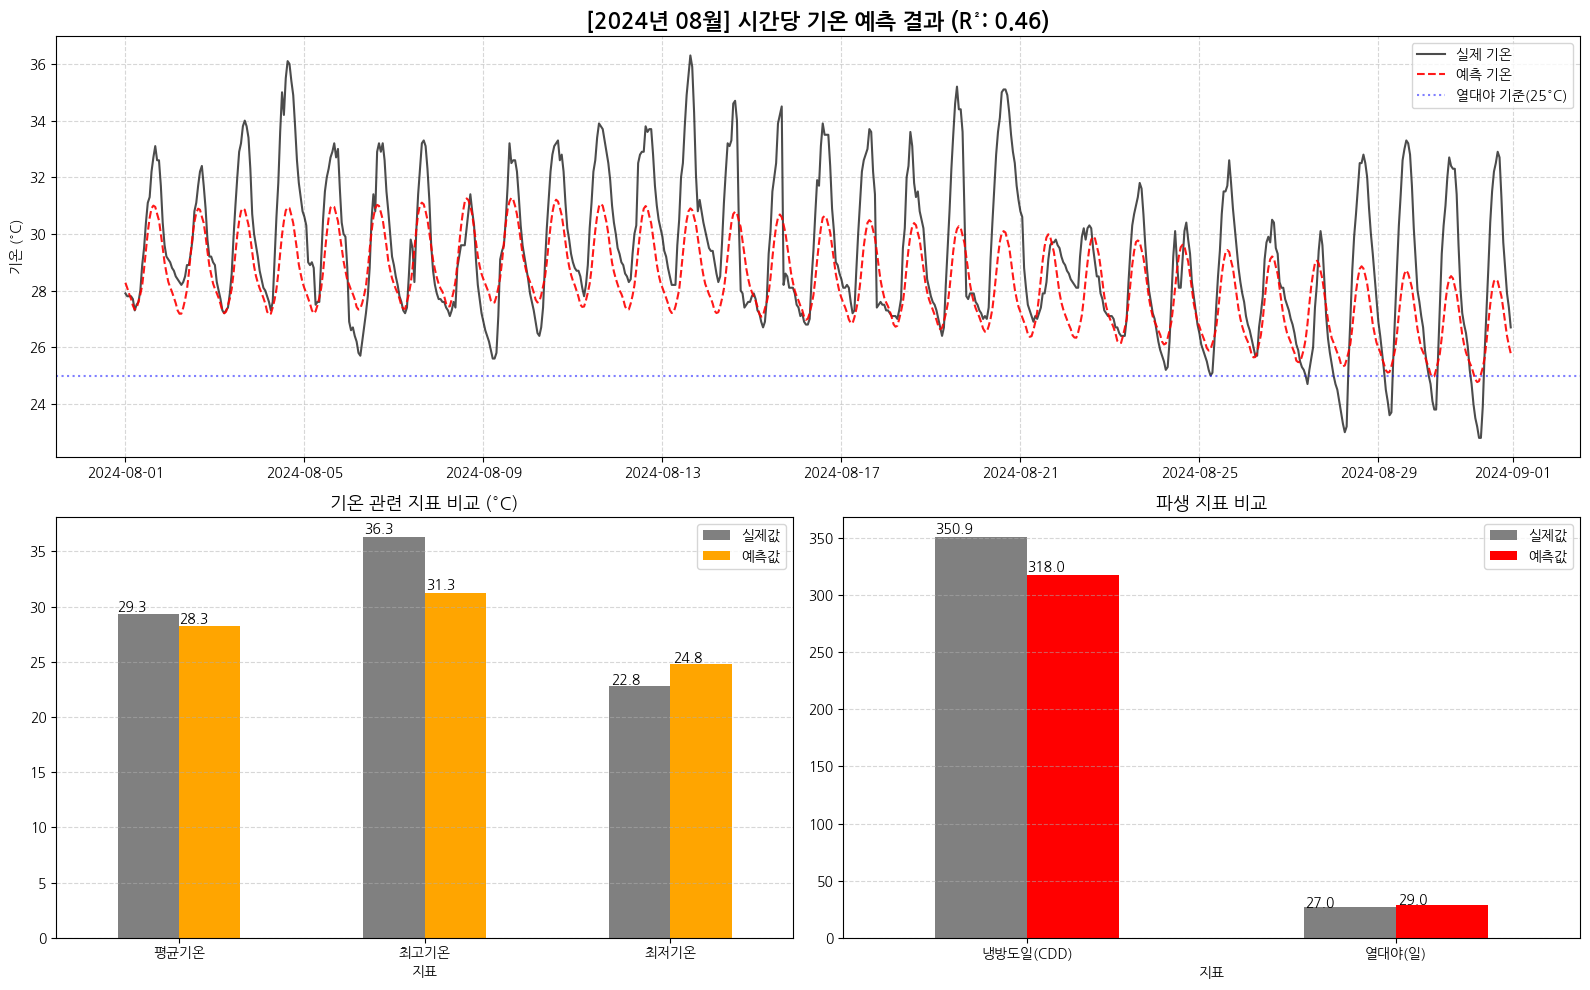

In [7]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import os

# ==========================================
# 0. GPU 및 한글 폰트 설정
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 중인 디바이스: {device}")

# 컨테이너 환경 한글 폰트 강제 적용
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(font_path):
    font_prop = fm.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False 

# ==========================================
# 1. 데이터 로드 및 피처 엔지니어링
# ==========================================
df = pd.read_csv('tr_data_2010_2025.csv')
df['일시'] = pd.to_datetime(df['일시'])
df = df.ffill().bfill() 

# 계절 매핑 (원핫 인코딩)
df['month'] = df['일시'].dt.month
def get_season(month):
    if month in [3, 4, 5]: return '봄'
    elif month in [6, 7, 8]: return '여름'
    elif month in[9, 10, 11]: return '가을'
    else: return '겨울'
df['계절'] = df['month'].apply(get_season)
season_dummies = pd.get_dummies(df['계절'], prefix='계절', dtype=float)
df = pd.concat([df, season_dummies], axis=1)
df.drop(columns=['month', '계절'], inplace=True)

# 시간, 일자 주기성 변수 (Sin/Cos)
df['hour'] = df['일시'].dt.hour
df['dayofyear'] = df['일시'].dt.dayofyear
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)
df['day_sin'] = np.sin(2 * np.pi * df['dayofyear'] / 365.25)
df['day_cos'] = np.cos(2 * np.pi * df['dayofyear'] / 365.25)

# 🚨 [추가] 밤 시간대 (18시~09시) 피처 추가 (열대야 예측 강화)
df['is_night'] = ((df['hour'] >= 18) | (df['hour'] < 9)).astype(float)

df.drop(columns=['hour', 'dayofyear'], inplace=True)

# 특성(Feature) 및 타겟(Target) 설정
feature_cols = df.columns.drop('일시').tolist()
num_features = len(feature_cols)
target_col = [col for col in feature_cols if '기온' in col][0] 
target_idx = feature_cols.index(target_col)
print(f"적용된 총 변수 개수: {num_features}개 (타겟: {target_col})")

# 스케일링
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df[feature_cols].values)

# ==========================================
# 2. 파라미터 및 모델 정의 (1달 예측용)
# ==========================================
seq_len = 720  # 과거 30일 (24시간 * 30일)
pred_len = 744 # 미래 31일 (24시간 * 31일, 가장 긴 달 기준)

class iTransformer_Residual(nn.Module):
    def __init__(self, seq_len, pred_len, num_features, d_model=128, nhead=8, num_layers=2):
        super(iTransformer_Residual, self).__init__()
        self.enc_embedding = nn.Linear(seq_len, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model*4, batch_first=True, dropout=0.1
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.projector = nn.Linear(d_model, pred_len)

    def forward(self, x):
        seq_mean = torch.mean(x, dim=1, keepdim=True)
        x_res = x - seq_mean  
        x_res = x_res.transpose(1, 2)  
        x_enc = self.enc_embedding(x_res)
        enc_out = self.encoder(x_enc)
        dec_out = self.projector(enc_out)
        out_res = dec_out.transpose(1, 2)
        return out_res + seq_mean

# ==========================================
# 3. 데이터셋 및 모델 학습
# ==========================================
class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_len, pred_len):
        self.data = data
        self.seq_len = seq_len
        self.pred_len = pred_len

    def __len__(self):
        return len(self.data) - self.seq_len - self.pred_len + 1

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_len]
        y = self.data[idx + self.seq_len : idx + self.seq_len + self.pred_len]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

dataset = TimeSeriesDataset(data_scaled, seq_len, pred_len)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

model = iTransformer_Residual(seq_len=seq_len, pred_len=pred_len, num_features=num_features).to(device)
criterion = nn.HuberLoss(delta=0.5) # delta를 낮춰 오차에 조금 더 민감하게 반응
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 15 # 시간 여유가 있다면 20 이상 권장
print(f"\n--- 모델 학습 시작 (총 {num_epochs} Epochs) ---")
model.train()
for epoch in range(num_epochs):
    epoch_loss = 0
    for batch_x, batch_y in dataloader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss/len(dataloader):.4f}")

# ==========================================
# 4. [설정 변수] 원하는 예측 시작 날짜 지정
# ==========================================
target_start_date_str = '2024-08-01'  # 👈 원하는 년-월-일로 변경하세요
target_start_date = pd.to_datetime(target_start_date_str + ' 00:00:00')

# 해당 월의 마지막 날짜 및 총 시간(시간당 데이터 개수) 계산
target_month_end = target_start_date + pd.offsets.MonthEnd(0) + pd.Timedelta(hours=23)
target_hours_count = int((target_month_end - target_start_date).total_seconds() / 3600) + 1

print(f"\n--- {target_start_date_str} 기준 1개월({target_hours_count}시간) 추론 시작 ---")

idx_start = df[df['일시'] == target_start_date].index[0]

# 입력 데이터 추출 및 텐서 변환
input_data = data_scaled[idx_start - seq_len : idx_start]
input_tensor = torch.tensor(input_data, dtype=torch.float32).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    predicted_tensor = model(input_tensor)

# 예측된 데이터를 numpy로 변환 및 스케일 복구
# (모델은 744시간을 뽑지만, 실제 해당 월의 시간수(ex. 30일이면 720시간)만큼만 자름)
pred_data_scaled = predicted_tensor.squeeze(0).cpu().numpy()[:target_hours_count, :]
pred_data = scaler.inverse_transform(pred_data_scaled)

# 실제 데이터 추출
actual_data_scaled = data_scaled[idx_start : idx_start + target_hours_count]
actual_data = scaler.inverse_transform(actual_data_scaled)

# 분석용 DataFrame 생성
dates = df['일시'].iloc[idx_start : idx_start + target_hours_count].reset_index(drop=True)
df_pred = pd.DataFrame(pred_data, index=dates, columns=feature_cols)
df_actual = pd.DataFrame(actual_data, index=dates, columns=feature_cols)

# ==========================================
# 5. 각종 지표 계산 함수 정의 (평균, 최고, 최저, CDD, 열대야)
# ==========================================
def calculate_metrics(df_temp):
    mean_t = df_temp[target_col].mean()
    max_t = df_temp[target_col].max()
    min_t = df_temp[target_col].min()
    
    # 🚨 기존 방식: 18도 기준 CDD (일평균 기온 기반이 아닌, 시간별 기온의 평균차)
    # 기존에 daily_stats['temp_mean']을 쓰셨다면, 
    # 현재 코드에서는 df_temp를 일별로 resample한 후 계산하는 것이 가장 정확합니다.
    
    df_daily = df_temp.resample('D').mean() # 시간별 데이터를 일별 평균으로 변환
    cdd = (df_daily[target_col] - 18.0).clip(lower=0).sum()
    
    # 열대야 (18:00 ~ 익일 09:00 사이 최저기온 >= 25도)
    tropical_nights = 0
    for day in pd.Series(df_temp.index.date).unique():
        night_data = df_temp[(df_temp.index.date == day) & ((df_temp.index.hour >= 18) | (df_temp.index.hour < 9))]
        if not night_data.empty and night_data[target_col].min() >= 25.0:
            tropical_nights += 1
            
    return mean_t, max_t, min_t, cdd, tropical_nights

act_metrics = calculate_metrics(df_actual)
pred_metrics = calculate_metrics(df_pred)
r2_val = r2_score(df_actual[target_col], df_pred[target_col])

# 지표 결과 DataFrame 생성
res_df = pd.DataFrame({
    '지표':['평균기온', '최고기온', '최저기온', '냉방도일(CDD)', '열대야(일)'],
    '실제값': act_metrics,
    '예측값': pred_metrics
}).set_index('지표')

print(f"\n[ R2 Score: {r2_val:.4f} ]")
print("-" * 40)
print(res_df.round(2))
print("-" * 40)

# ==========================================
# 6. 시각화 (시간당 추세선 + 지표 비교 막대그래프)
# ==========================================
fig = plt.figure(figsize=(16, 10))

# 1) 전체 1달 시간당 기온 그래프
ax1 = plt.subplot(2, 1, 1)
ax1.plot(df_actual.index, df_actual[target_col], label='실제 기온', color='black', alpha=0.7)
ax1.plot(df_pred.index, df_pred[target_col], label='예측 기온', color='red', alpha=0.9, linestyle='--')
ax1.axhline(25, color='blue', linestyle=':', alpha=0.5, label='열대야 기준(25°C)')
ax1.set_title(f"[{target_start_date.strftime('%Y년 %m월')}] 시간당 기온 예측 결과 (R²: {r2_val:.2f})", fontsize=16, fontweight='bold')
ax1.set_ylabel('기온 (°C)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# 2) 온도 관련 지표 비교 (평균, 최고, 최저)
ax2 = plt.subplot(2, 2, 3)
res_df.loc[['평균기온', '최고기온', '최저기온']].plot(kind='bar', ax=ax2, color=['gray', 'orange'], rot=0)
ax2.set_title('기온 관련 지표 비교 (°C)', fontsize=13)
for p in ax2.patches:
    ax2.annotate(f"{p.get_height():.1f}", (p.get_x() * 1.005, p.get_height() * 1.01))
ax2.grid(axis='y', linestyle='--', alpha=0.5)

# 3) CDD 및 열대야 비교
ax3 = plt.subplot(2, 2, 4)
res_df.loc[['냉방도일(CDD)', '열대야(일)']].plot(kind='bar', ax=ax3, color=['gray', 'red'], rot=0)
ax3.set_title('파생 지표 비교', fontsize=13)
for p in ax3.patches:
    ax3.annotate(f"{p.get_height():.1f}", (p.get_x() * 1.005, p.get_height() * 1.01))
ax3.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import os
import random

# ==========================================
# 0. GPU 및 시드 고정 설정
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 중인 디바이스: {device}")

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# ==========================================
# 1. 데이터 로드 및 피처 엔지니어링
# ==========================================
df = pd.read_csv('tr_data_2010_2025.csv')
df['일시'] = pd.to_datetime(df['일시'])
df = df.ffill().bfill() 

# 계절 및 시간 주기성 피처 생성
df['month'] = df['일시'].dt.month
def get_season(month):
    if month in[3, 4, 5]: return '봄'
    elif month in [6, 7, 8]: return '여름'
    elif month in[9, 10, 11]: return '가을'
    else: return '겨울'
df['계절'] = df['month'].apply(get_season)
season_dummies = pd.get_dummies(df['계절'], prefix='계절', dtype=float)
df = pd.concat([df, season_dummies], axis=1)

df['hour'] = df['일시'].dt.hour
df['dayofyear'] = df['일시'].dt.dayofyear
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)
df['day_sin'] = np.sin(2 * np.pi * df['dayofyear'] / 365.25)
df['day_cos'] = np.cos(2 * np.pi * df['dayofyear'] / 365.25)
df['is_night'] = ((df['hour'] >= 18) | (df['hour'] < 9)).astype(float)
df.drop(columns=['month', '계절', 'hour', 'dayofyear'], inplace=True)

feature_cols = df.columns.drop('일시').tolist()
num_features = len(feature_cols)

# 🚨 타겟을 '기온'으로 설정
target_col =[col for col in feature_cols if '기온' in col][0] 
print(f"적용된 총 변수 개수: {num_features}개 (타겟: {target_col})")

scaler = StandardScaler()
data_scaled = scaler.fit_transform(df[feature_cols].values)

# ==========================================
# 2. 파라미터 및 모델 정의
# ==========================================
seq_len = 720  
pred_len = 744 

class iTransformer_Residual(nn.Module):
    def __init__(self, seq_len, pred_len, num_features, d_model=128, nhead=8, num_layers=2):
        super(iTransformer_Residual, self).__init__()
        self.enc_embedding = nn.Linear(seq_len, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model*4, batch_first=True, dropout=0.1
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.projector = nn.Linear(d_model, pred_len)

    def forward(self, x):
        seq_mean = torch.mean(x, dim=1, keepdim=True)
        x_res = x - seq_mean  
        x_res = x_res.transpose(1, 2)  
        x_enc = self.enc_embedding(x_res)
        enc_out = self.encoder(x_enc)
        dec_out = self.projector(enc_out)
        out_res = dec_out.transpose(1, 2)
        return out_res + seq_mean

# ==========================================
# 3. 앙상블 모델 학습 및 로드 (메모리에 캐싱)
# ==========================================
seeds =[42, 123, 7, 999, 2024]
ensemble_models =[]

class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_len, pred_len):
        self.data = data
        self.seq_len = seq_len
        self.pred_len = pred_len
    def __len__(self): return len(self.data) - self.seq_len - self.pred_len + 1
    def __getitem__(self, idx): return torch.tensor(self.data[idx:idx+self.seq_len], dtype=torch.float32), torch.tensor(self.data[idx+self.seq_len:idx+self.seq_len+self.pred_len], dtype=torch.float32)

dataset = TimeSeriesDataset(data_scaled, seq_len, pred_len)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

print("\n--- 앙상블 모델(5개) 준비 중 ---")
for seed in seeds:
    model_path = f'itransformer_temp_seed_{seed}.pth'
    model = iTransformer_Residual(seq_len=seq_len, pred_len=pred_len, num_features=num_features).to(device)
    
    # 모델 파일이 없으면 학습 진행
    if not os.path.exists(model_path):
        print(f"[{seed}] 학습된 모델이 없어 새로 학습을 시작합니다...")
        set_seed(seed)
        criterion = nn.HuberLoss(delta=0.5)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        model.train()
        for epoch in range(10): # 10 Epochs
            for batch_x, batch_y in dataloader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                optimizer.zero_grad()
                loss = criterion(model(batch_x), batch_y)
                loss.backward()
                optimizer.step()
        torch.save(model.state_dict(), model_path)
    
    # 모델 가중치 로드 후 리스트에 추가 (추론 속도 향상)
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.eval()
    ensemble_models.append(model)

print("--- 모델 준비 완료! ---")

# ==========================================
# 4. 2024년 1월 ~ 12월 월간 지표 예측 (앙상블)
# ==========================================
print("\n--- 2024년 1월 ~ 12월 월간 지표 추론 시작 ---")
temp_results =[]

for month in range(1, 13):
    target_start_date_str = f'2024-{month:02d}-01'
    target_start_date = pd.to_datetime(target_start_date_str + ' 00:00:00')

    # 데이터 존재 확인
    candidates = df[df['일시'] >= target_start_date]
    if candidates.empty:
        print(f"경고: {target_start_date_str} 이후의 데이터가 없습니다.")
        continue
        
    idx_start = candidates.index[0]
    actual_start_date = df.loc[idx_start, '일시']
    
    # 🚨[추가됨] 해당 월의 예측해야 할 총 시간 계산
    target_month_end = actual_start_date + pd.offsets.MonthEnd(0) + pd.Timedelta(hours=23)
    target_hours_count = int((target_month_end - actual_start_date).total_seconds() / 3600) + 1

    print(f"처리 중: {target_start_date_str} -> 실제 시작 데이터: {actual_start_date} ({target_hours_count}시간 예측)")

    # 입력 데이터 추출
    input_data = data_scaled[idx_start - seq_len : idx_start]
    input_tensor = torch.tensor(input_data, dtype=torch.float32).unsqueeze(0).to(device)

    # ==============================
    # 5개의 앙상블 모델 예측 수행
    # ==============================
    all_predictions =[]
    with torch.no_grad():
        for model in ensemble_models:
            pred_scaled = model(input_tensor).squeeze(0).cpu().numpy()[:target_hours_count, :]
            pred_data = scaler.inverse_transform(pred_scaled)
            all_predictions.append(pred_data)
            
    # 예측값 평균 (앙상블)
    final_pred_data = np.mean(all_predictions, axis=0)

    # DataFrame 생성 (인덱스를 datetime으로 설정해야 resample 가능)
    dates = df['일시'].iloc[idx_start : idx_start + target_hours_count].reset_index(drop=True)
    df_pred = pd.DataFrame(final_pred_data, index=dates, columns=feature_cols)

    # ==============================
    # 해당 월의 기온 지표 계산
    # ==============================
    mean_t = df_pred[target_col].mean()
    max_t = df_pred[target_col].max()
    min_t = df_pred[target_col].min()
    
    # 냉방도일 (CDD) - 일평균 기온 18도 기준
    df_daily = df_pred[target_col].resample('D').mean()
    cdd = (df_daily - 18.0).clip(lower=0).sum()
    
    # 열대야 일수
    tropical_nights = 0
    for day in pd.Series(df_pred.index.date).unique():
        night_data = df_pred[(df_pred.index.date == day) & ((df_pred.index.hour >= 18) | (df_pred.index.hour < 9))]
        if not night_data.empty and night_data[target_col].min() >= 25.0:
            tropical_nights += 1

    # 결과 리스트에 추가
    temp_results.append({
        '월': f'{month}월',
        '온도_평균': mean_t,
        '온도_최고': max_t,
        '온도_최저': min_t,
        '냉방도일': cdd,
        '열대야일수': tropical_nights
    })
    
    print(f" -> [{month}월] 예측 및 지표 계산 완료")

# ==========================================
# 5. 결과를 DataFrame으로 변환 및 CSV 저장
# ==========================================
df_temp_results = pd.DataFrame(temp_results)
df_temp_results.to_csv('monthly_temp_results_ensemble.csv', index=False, encoding='utf-8-sig')

print("\n--- 전체 처리 완료 ---")
print("결과가 'monthly_temp_results_ensemble.csv'에 성공적으로 저장되었습니다.")
print(df_temp_results)

사용 중인 디바이스: cuda
적용된 총 변수 개수: 44개 (타겟: 기온(°C))

--- 앙상블 모델(5개) 준비 중 ---
[42] 학습된 모델이 없어 새로 학습을 시작합니다...
[123] 학습된 모델이 없어 새로 학습을 시작합니다...
[7] 학습된 모델이 없어 새로 학습을 시작합니다...
[999] 학습된 모델이 없어 새로 학습을 시작합니다...
[2024] 학습된 모델이 없어 새로 학습을 시작합니다...
--- 모델 준비 완료! ---

--- 2024년 1월 ~ 12월 월간 지표 추론 시작 ---
처리 중: 2024-01-01 -> 실제 시작 데이터: 2024-01-01 01:00:00 (744시간 예측)
 -> [1월] 예측 및 지표 계산 완료
처리 중: 2024-02-01 -> 실제 시작 데이터: 2024-02-01 00:00:00 (696시간 예측)
 -> [2월] 예측 및 지표 계산 완료
처리 중: 2024-03-01 -> 실제 시작 데이터: 2024-03-01 00:00:00 (744시간 예측)
 -> [3월] 예측 및 지표 계산 완료
처리 중: 2024-04-01 -> 실제 시작 데이터: 2024-04-01 00:00:00 (720시간 예측)
 -> [4월] 예측 및 지표 계산 완료
처리 중: 2024-05-01 -> 실제 시작 데이터: 2024-05-01 00:00:00 (744시간 예측)
 -> [5월] 예측 및 지표 계산 완료
처리 중: 2024-06-01 -> 실제 시작 데이터: 2024-06-01 00:00:00 (720시간 예측)
 -> [6월] 예측 및 지표 계산 완료
처리 중: 2024-07-01 -> 실제 시작 데이터: 2024-07-01 00:00:00 (744시간 예측)
 -> [7월] 예측 및 지표 계산 완료
처리 중: 2024-08-01 -> 실제 시작 데이터: 2024-08-01 00:00:00 (744시간 예측)
 -> [8월] 예측 및 지표 계산 완료
처리 중: 2024-09-01 -> 실제 시작 데이터: 